# Predictive Analytics: SVR trained on the residual over base_demand

We predict taxi pickup demand (`Total_Trip_Start`) with an SVR, at **every spatial and
temporal granularity** the discretization in `1.4` produces — four spatial levels (H3 Res-7, H3 Res-8,
Census Tract, Community Area) crossed with two temporal levels (hourly, daily).

While `3.2a PredictionSVM_Standard.ipynb` fits an SVR to predict log1p(demand) directly, this notebook tests tests to fit the SVR on the *residual* instead of the total.
The target becomes the log-space correction log1p(demand) - log1p(base_demand), reconstructed as demand_hat = expm1(log1p(base_demand) + correction_hat), with a full, independent kernel scan and hyperparameter search run *directly on the residual target*, for all 8 levels, evaluated once on the test set exactly as `3.2a` does for its own winners. The residual target has a much smaller scale/variance than `log1p(demand)`, so hyperparameters tuned for the original target are not necessarily the right
ones here.

In [ ]:
# Run the common ground notebook to set up the environment and import necessary libraries and define functions and variables that are used in this notebook.
%run "3.2 Prediction_CommonGround.ipynb"

In [ ]:
import gc
import warnings
from pathlib import Path 

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(RANDOM_STATE)

MODELS_DIR = Path("..") / "models_predictions" / "SVR" / "residual"
SVR_DIR = MODELS_DIR / "models"
PRED_DIR = MODELS_DIR / "predictions"
DIRECT_SVR_DIR = Path("..") / "models_predictions" / "SVR" / "standard" / "models"  # 3.2a's models and level_comparison

N_CV_SPLITS = 3  # folds for the manual residual grid search (matches 3.2a's GridSearchCV cv=3)

# sklearn's SVR defaults to max_iter=-1 (unbounded LIBSVM iterations). Some (C, gamma) combinations
# fail to converge in reasonable time. A large but finite cap ends a non-converging fit.
SVR_MAX_ITER = 50_000

## 1. The eight levels

SPATIAL_LEVELS, TEMPORAL_LEVELS, LEVELS, and load_splits get imported from  `3.2 Prediction_CommonGround.ipynb`. 

Each split is at `data/prediction_split/<spatial>/<temporal>/{train,val,test}.parquet`


In [ ]:
# Overview of what we are about to train on. The zero share differs a lot between the different spatial 
# and temporal levels, which is important to keep in mind when interpreting the results.
overview = []
for spatial, temporal in LEVELS:
    df = pd.read_parquet(SPLIT_DIR / spatial / temporal / "train.parquet",
                         columns=[SPATIAL_LEVELS[spatial], TARGET])
    overview.append({
        "spatial": spatial, "temporal": temporal,
        "units": df[SPATIAL_LEVELS[spatial]].nunique(),
        "train rows": len(df),
        "mean demand": df[TARGET].mean(),
        "zero %": (df[TARGET] == 0).mean() * 100,
    })
    del df

pd.DataFrame(overview).round(2)


## 2. Feature sets

All `feature_sets` get imported from `3.2 Prediction_CommonGround.ipynb`


In [ ]:
for temporal in TEMPORAL_LEVELS:
    sizes = {name: len(f) for name, f in feature_sets(temporal).items()}
    print(f"{temporal:7s} {sizes}")

## 3. Pipeline
### Kernel scan and grid search on the residual target

**This is the one place in the pipeline that structurally diverges from** `3.2a` (every other
section (registry, feature sets, training-loop shape, level-comparison table) is unchanged):

**Residual target, not log1p(y) directly.** 

The model is fit to log1p(demand) - log1p(base_demand) and reconstructed as demand_hat = expm1(log1p(base_demand) + correction_hat). This has a built-in floor: a correction of exactly 0 everywhere reproduces base_demand exactly, i.e. skill = 0. Any improvement found here is a genuine addition. 

`3.2a` scores by computing to_counts(y_log) vs. to_counts(estimator.predict(X)) (y_log = log1p(demand)). If the model predicts a *residual* instead, turning that back into counts needs the row's base_demand, which a standard sklearn scorer never sees. That is why a custom GridSearch with KFold is needed.

In [ ]:
def find_best_kernel_residual(Xs, y_resid_s, base_log1p_val, X_val, y_val_true):
    """Scan kernels at fixed hyperparameters on the residual target; pick by validation R2 in count
    space after adding base_demand's log1p back in."""
    val_r2 = {}
    for kernel in KERNELS:
        svr = SVR(kernel=kernel, C=1.0, gamma="scale", cache_size=500, max_iter=SVR_MAX_ITER)
        svr.fit(Xs, y_resid_s)
        log1p_pred = np.clip(base_log1p_val + svr.predict(X_val), -LOG_CEILING, LOG_CEILING)
        val_r2[kernel] = r2_score(y_val_true, to_counts(log1p_pred))
        print(f"      SVR({kernel:6s}) val R2 = {val_r2[kernel]:12.4f}")
    best = max(val_r2, key=val_r2.get)
    print(f"      -> best kernel: {best}")
    return best, val_r2


def _score_params(params, X_all, base_log1p_all, y_resid_all, y_true_all, kernel, fold_splits):
    """One parameter combination's mean CV MAE, all folds fit sequentially inside the worker --
    parallelism is across parameter combinations (9 for rbf/linear, 18 for poly), not folds.

    The ConvergenceWarning filter set in cell 1 does NOT reach here: joblib's spawn-based worker
    processes (the default on macOS) do not inherit the parent process's runtime
    warnings.filterwarnings() state, only whatever is set inside the code that actually runs in the
    worker -- confirmed by direct reproduction. So the filter is set again, right here.
    """
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    fold_maes = []
    for train_idx, val_idx in fold_splits:
        model = SVR(kernel=kernel, cache_size=500, max_iter=SVR_MAX_ITER, **params)
        model.fit(X_all[train_idx], y_resid_all[train_idx])
        log1p_pred = np.clip(base_log1p_all[val_idx] + model.predict(X_all[val_idx]),
                              -LOG_CEILING, LOG_CEILING)
        fold_maes.append(mean_absolute_error(y_true_all[val_idx], to_counts(log1p_pred)))
    return params, float(np.mean(fold_maes))


def grid_search_svr_residual(X_all, base_log1p_all, y_resid_all, y_true_all, kernel,
                             n_splits=N_CV_SPLITS, seed=RANDOM_STATE, n_jobs=-1):
    """Manual K-fold CV over C/gamma (+ degree for poly), scored by count-space MAE after
    reconstructing counts from the residual prediction. Refits on the full sample at the winning
    parameters, exactly as GridSearchCV's refit=True does in 3.2a.

    Takes the already-scaled feature matrix and the raw base_demand/target arrays separately,
    rather than a single DataFrame -- `base_demand` is itself one of the input features, so scaling
    it in place and then reading it back out for the log1p offset would silently use the scaled
    (mean 0, std 1) value instead of the real historical mean.

    Parallelized across parameter combinations with joblib -- sklearn's GridSearchCV(n_jobs=-1),
    which this replaces, does the same. A purely sequential loop here means one slow-to-converge
    (C, gamma) combination (LIBSVM's SMO solver can be much slower on some settings than others,
    especially on a target as bimodal as the residual is at heavily zero-inflated levels) blocks
    every other combination behind it instead of running alongside them."""
    param_grid = {"C": [1, 10, 50], "gamma": ["scale", 0.05, 0.2]}
    if kernel == "poly":
        param_grid["degree"] = [2, 3]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_splits = list(kf.split(X_all))

    results = Parallel(n_jobs=n_jobs)(
        delayed(_score_params)(params, X_all, base_log1p_all, y_resid_all, y_true_all, kernel, fold_splits)
        for params in ParameterGrid(param_grid)
    )
    best_params, best_mae = min(results, key=lambda r: r[1])

    print(f"      best params: {best_params}")
    final_model = SVR(kernel=kernel, cache_size=500, max_iter=SVR_MAX_ITER, **best_params)
    final_model.fit(X_all, y_resid_all)
    return final_model, best_params


def train_feature_set_residual(df_train, df_val_s, features, spatial, temporal, set_name):
    """Fit one (level, feature set) configuration on the residual target and return its bundle."""
    scaler = StandardScaler().fit(df_train[features])
    X_val = scaler.transform(df_val_s[features])
    base_log1p_val = np.log1p(df_val_s["base_demand"].values)
    y_val = df_val_s[TARGET].values

    scan = balanced_sample(df_train, N_SCAN)
    Xs = scaler.transform(scan[features])
    y_resid_s = np.log1p(scan[TARGET].values) - np.log1p(scan["base_demand"].values)
    best_kernel, kernel_r2 = find_best_kernel_residual(Xs, y_resid_s, base_log1p_val, X_val, y_val)

    sample = balanced_sample(df_train, N_GRID)
    X_grid = scaler.transform(sample[features])
    base_log1p_grid = np.log1p(sample["base_demand"].values)
    y_resid_grid = np.log1p(sample[TARGET].values) - base_log1p_grid
    y_true_grid = sample[TARGET].values
    tuned, best_params = grid_search_svr_residual(
        X_grid, base_log1p_grid, y_resid_grid, y_true_grid, best_kernel)

    log1p_pred_val = np.clip(base_log1p_val + tuned.predict(X_val), -LOG_CEILING, LOG_CEILING)
    val_metrics = score(y_val, to_counts(log1p_pred_val),
                        f"SVR-residual {spatial}/{temporal} ({set_name}, {best_kernel})")

    return {
        "model": tuned,
        "scaler": scaler,
        "features": features,
        "spatial": spatial,
        "temporal": temporal,
        "spatial_key": SPATIAL_LEVELS[spatial],
        "feature_set": set_name,
        "kernel": best_kernel,
        "kernel_r2": kernel_r2,
        "best_params": best_params,
        "target": "residual_log1p_over_base_demand",
        "val_metrics": val_metrics,
    }

## 4. Training

One pass per level: load the splits once, train all four feature sets, pick the winner on validation, evaluate that winner once on the full validation split, save it.

The result is 32 bundles, keyed by (spatial, temporal, feature_set)


In [ ]:
#| label: tbl-svr-residual2-val-metrics
#| tbl-cap: "Validation performance per level: baselines vs. the tuned residual-on-baseline SVR for each feature set (hyperparameters searched directly on the residual target)."
SVR_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

bundles = {}      # (spatial, temporal, feature_set) -> bundle
val_rows = []
test_rows = []

for spatial, temporal in LEVELS:
    print(f"\n{'=' * 70}\n{spatial} / {temporal}\n{'=' * 70}")
    df_train, df_val, df_test = load_splits(spatial, temporal)
    key = SPATIAL_LEVELS[spatial]

    df_val_s = df_val.sample(n=min(N_VAL_SUBSAMPLE, len(df_val)), random_state=RANDOM_STATE)
    y_val_s = df_val_s[TARGET].values
    print(f"train {len(df_train):>9,} | val {len(df_val):>9,} (subsample {len(df_val_s):,}) "
          f"| test {len(df_test):>9,} | zeros {(df_train[TARGET] == 0).mean():.1%}")

    for name, metrics in [
        ("Baseline: always zero", score(y_val_s, np.zeros(len(y_val_s)), "Baseline: always zero")),
        ("Baseline: historical mean (base_demand)",
         score(y_val_s, df_val_s["base_demand"].values, "Baseline: historical mean (base_demand)")),
    ]:
        val_rows.append({"spatial": spatial, "temporal": temporal, **metrics})

    for set_name, features in feature_sets(temporal).items():
        print(f"\n   feature set: {set_name} ({len(features)} features)")
        bundle = train_feature_set_residual(df_train, df_val_s, features, spatial, temporal, set_name)
        bundles[(spatial, temporal, set_name)] = bundle
        val_rows.append({"spatial": spatial, "temporal": temporal, **bundle["val_metrics"]})
        print(f"      val: MAE={bundle['val_metrics']['MAE']:.3f}  "
              f"R2={bundle['val_metrics']['R2']:.4f}")

    level_sets = {k[2]: b for k, b in bundles.items() if k[0] == spatial and k[1] == temporal}
    best_set = max(level_sets, key=lambda s: level_sets[s]["val_metrics"]["R2"])
    best = level_sets[best_set]
    print(f"\n   -> winner: {best_set} ({best['kernel']}); scoring on the full test split...")

    y_test = df_test[TARGET].values
    base_test = score(y_test, df_test["base_demand"].values, "Baseline: historical mean (base_demand)")
    zero_test = score(y_test, np.zeros(len(y_test)), "Baseline: always zero")

    X_test = best["scaler"].transform(df_test[best["features"]])
    base_log1p_test = np.log1p(df_test["base_demand"].values)
    log1p_pred_test = np.clip(base_log1p_test + best["model"].predict(X_test), -LOG_CEILING, LOG_CEILING)
    test_pred = to_counts(log1p_pred_test)
    model_test = score(y_test, test_pred, f"SVR-residual ({best_set}, {best['kernel']})")

    best["test_metrics"] = model_test
    best["baseline_test_metrics"] = base_test
    best["skill"] = skill(model_test, base_test)
    best["is_level_winner"] = True

    for m in (zero_test, base_test, model_test):
        test_rows.append({"spatial": spatial, "temporal": temporal, **m})

    print(f"      test: MAE={model_test['MAE']:.3f}  R2={model_test['R2']:.4f}  "
          f"skill vs base_demand: {best['skill']['skill_MAE']:+.1%} MAE")

    out_dir = SVR_DIR / spatial / temporal
    out_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(best, out_dir / "best.joblib")

    pd.DataFrame({
        key: df_test[key].values,
        "timestamp": df_test["timestamp"].values,
        "y_true": y_test,
        "y_pred": test_pred,
    }).to_parquet(PRED_DIR / f"{spatial}_{temporal}.parquet", index=False)

    del df_train, df_val, df_val_s, df_test, test_pred
    gc.collect()

print(f"\n\nTrained {len(bundles)} configurations across {len(LEVELS)} levels.")

val_metrics = (pd.DataFrame(val_rows)
               .set_index(["spatial", "temporal", "Model"])
               .round(4))
val_metrics



h3_7 / hourly
train 1,230,936 | val   494,088 (subsample 50,000) | test   739,704 | zeros 93.6%

   feature set: basic (12 features)


      SVR(linear) val R2 =       0.9074


      SVR(poly  ) val R2 =       0.9042


      SVR(rbf   ) val R2 =       0.9161
      -> best kernel: rbf


/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


...

/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/tjorgeorlitz/Documents/Uni/Semester 2/AAA/Project/AAA_Project_Group7/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


      best params: {'C': 1, 'gamma': 'scale'}


      val: MAE=40.101  R2=0.9484

   -> winner: basic (rbf); scoring on the full test split...


      test: MAE=47.984  R2=0.9400  skill vs base_demand: +9.1% MAE


Trained 32 configurations across 8 levels.


MAE  \
spatial   temporal Model                                                          
h3_7      hourly   Baseline: always zero                                 3.0503   
                   Baseline: historical mean (base_demand)               1.0236   
                   SVR-residual h3_7/hourly (basic, rbf)                 0.9138   
                   SVR-residual h3_7/hourly (basic+poi, rbf)             0.9383   
                   SVR-residual h3_7/hourly (basic+weather, rbf)         0.9583   
                   SVR-residual h3_7/hourly (basic+poi+weather, rbf)     0.9725   
          daily    Baseline: always zero                                71.6167   
                   Baseline: historical mean (base_demand)              18.0772   
                   SVR-residual h3_7/daily (basic, rbf)                 14.2474   
                   SVR-residual h3_7/daily (basic+poi, linear)          17.2556   
                   SVR-residual h3_7/daily (basic+weather, rbf)         14.4811   
                   SVR-residual h3_7/daily (basic+poi+weather, rbf)     14.3277   
h3_8      hourly   Baseline: always zero                                 0.7768   
                   Baseline: historical mean (base_demand)               0.2994   
                   SVR-residual h3_8/hourly (basic, linear)              0.3404   
                   SVR-residual h3_8/hourly (basic+poi, poly)            0.3654   
                   SVR-residual h3_8/hourly (basic+weather, rbf)         0.3401   
                   SVR-residual h3_8/hourly (basic+poi+weather, rbf)     0.3543   
          daily    Baseline: always zero                                19.1863   
                   Baseline: historical mean (base_demand)               5.1226   
                   SVR-residual h3_8/daily (basic, rbf)                  4.2039   
                   SVR-residual h3_8/daily (basic+poi, rbf)              4.3360   
                   SVR-residual h3_8/daily (basic+weather, rbf)          4.4526   
                   SVR-residual h3_8/daily (basic+poi+weather, rbf)      4.3492   
census    hourly   Baseline: always zero                                 0.5831   
                   Baseline: historical mean (base_demand)               0.2414   
                   SVR-residual census/hourly (basic, rbf)               0.2911   
                   SVR-residual census/hourly (basic+poi, rbf)           0.2906   
                   SVR-residual census/hourly (basic+weather, rbf)       0.2903   
                   SVR-residual census/hourly (basic+poi+weather, ...    0.2841   
          daily    Baseline: always zero                                14.0741   
                   Baseline: historical mean (base_demand)               3.8677   
                   SVR-residual census/daily (basic, linear)             3.5782   
                   SVR-residual census/daily (basic+poi, rbf)            3.3693   
                   SVR-residual census/daily (basic+weather, rbf)        3.3565   
                   SVR-residual census/daily (basic+poi+weather, rbf)    3.3804   
community hourly   Baseline: always zero                                 9.6129   
                   Baseline: historical mean (base_demand)               2.9386   
                   SVR-residual community/hourly (basic, linear)         2.8989   
                   SVR-residual community/hourly (basic+poi, linear)     2.9814   
                   SVR-residual community/hourly (basic+weather, l...    3.0319   
                   SVR-residual community/hourly (basic+poi+weathe...    2.8958   
          daily    Baseline: always zero                               231.0757   
                   Baseline: historical mean (base_demand)              41.7484   
                   SVR-residual community/daily (basic, rbf)            33.8422   
                   SVR-residual community/daily (basic+poi, linear)     37.8295   
                   SVR-residual community/daily (basic+weather, rbf)    35.0877   
         

## 5. Comparing the levels

Raw MAE is not comparable across levels. Mean demand runs from 0.73 trips per hexagon-hour at
h3_8/hourly to 213 trips per area-day at community/daily. On raw MAE the finest grid would always look best simply because there is less to be wrong about.

The **skill score** fixes this: `1 - MAE_model / MAE_base_demand`. 
- It asks whether the SVR beats the historical-mean baseline *on its own ground*, and that comparison transfers across levels. 
- A skill of 0 means the model has learned nothing the historical average did not already know; 
- negative means it is actively worse.
- Higher skill score -> better prediction


In [ ]:
#| label: tbl-svr-residual2-level-comparison
#| tbl-cap: "Winning SVR per level, with skill against the historical-mean baseline."
comparison = []
for spatial, temporal in LEVELS:
    best = next(b for k, b in bundles.items()
                if k[0] == spatial and k[1] == temporal and b.get("is_level_winner"))
    comparison.append({
        "spatial": spatial,
        "temporal": temporal,
        "feature_set": best["feature_set"],
        "kernel": best["kernel"],
        "C": best["best_params"].get("C"),
        "gamma": best["best_params"].get("gamma"),
        "test_MAE": best["test_metrics"]["MAE"],
        "test_RMSE": best["test_metrics"]["RMSE"],
        "test_R2": best["test_metrics"]["R2"],
        "base_MAE": best["baseline_test_metrics"]["MAE"],
        "skill_MAE": best["skill"]["skill_MAE"],
        "skill_RMSE": best["skill"]["skill_RMSE"],
    })

level_comparison = pd.DataFrame(comparison).sort_values("skill_MAE", ascending=False)
level_comparison.to_csv(SVR_DIR / "level_comparison.csv", index=False)
level_comparison.round(4).reset_index(drop=True)


,spatial,temporal,feature_set,kernel,C,gamma,test_MAE,test_RMSE,test_R2,base_MAE,skill_MAE,skill_RMSE
0,h3_7,daily,basic,rbf,10,scale,19.1517,113.5153,0.9208,22.0992,0.1334,0.1112
1,h3_8,daily,basic,rbf,1,0.2,5.5823,36.5771,0.9197,6.2982,0.1137,0.1322
2,community,daily,basic,rbf,1,scale,47.9839,176.5009,0.9400,52.8156,0.0915,0.0886
3,h3_7,hourly,basic,rbf,10,0.05,1.0516,7.3871,0.8857,1.1519,0.0870,0.0988
4,census,daily,basic+weather,rbf,1,scale,4.4068,29.5805,0.9079,4.6938,0.0612,0.0927
5,community,hourly,basic,linear,1,scale,3.0628,11.9763,0.8970,3.2476,0.0569,0.0489
6,census,hourly,basic+weather,rbf,1,0.05,0.2993,2.1114,0.8507,0.2642,-0.1327,0.0603
7,h3_8,hourly,basic+poi,poly,1,scale,0.3927,2.6278,0.8690,0.3427,-0.1459,0.0906


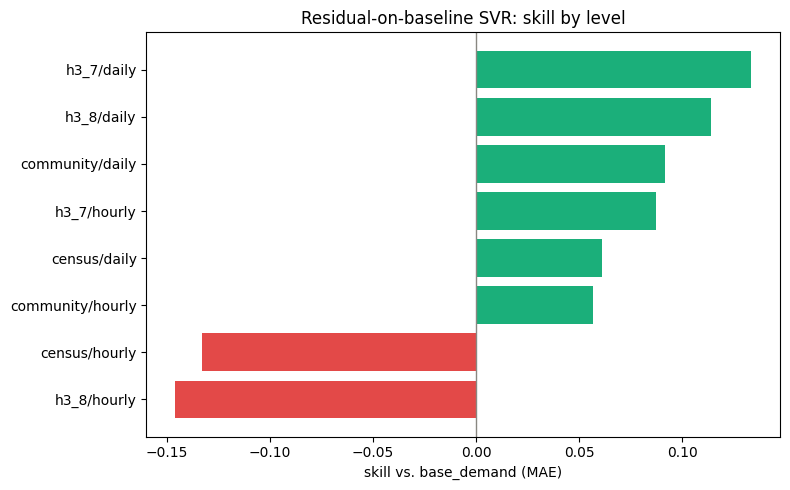

In [ ]:
#| label: fig-svr-residual2-skill-by-level
#| fig-cap: "SVR skill against the historical-mean baseline, by spatial and temporal granularity."
plot_df = level_comparison.assign(level=level_comparison.spatial + "/" + level_comparison.temporal)
plot_df = plot_df.set_index("level")["skill_MAE"].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e34948" if v < 0 else "#1baf7a" for v in plot_df.values]
ax.barh(plot_df.index, plot_df.values, color=colors)
ax.axvline(0, color="#898781", linewidth=1)
ax.set_xlabel("skill vs. base_demand (MAE)")
ax.set_title("Residual-on-baseline SVR: skill by level")
fig.tight_layout()
plt.show()


## 6. Direct vs. residual: The Comparison

Section 5 compared this notebook's own 8 levels against each other. The comparison that actually
matters is against `3.2a`'s own winning configuration per level
both notebooks evaluate on the same held-out test split, so this is exact, not approximate.

In [ ]:
#| label: tbl-svr-direct-vs-residual-final
#| tbl-cap: "Direct SVR (3.2a) vs. residual-on-baseline SVR trained from scratch (this notebook), per level, on test."
direct_comparison = pd.read_csv(DIRECT_SVR_DIR / "level_comparison.csv")

final_comparison = level_comparison.merge(
    direct_comparison[["spatial", "temporal", "skill_MAE", "test_MAE"]],
    on=["spatial", "temporal"], suffixes=("_residual", "_direct"),
)
final_comparison["delta_skill_MAE"] = (
    final_comparison["skill_MAE_residual"] - final_comparison["skill_MAE_direct"]
)
final_comparison = final_comparison.sort_values("delta_skill_MAE", ascending=False)
final_comparison.to_csv(SVR_DIR / "direct_vs_residual_final.csv", index=False)
final_comparison[["spatial", "temporal", "feature_set", "kernel",
                  "skill_MAE_direct", "skill_MAE_residual", "delta_skill_MAE"]].round(4).reset_index(drop=True)

In [ ]:
#| label: fig-svr-direct-vs-residual-final
#| fig-cap: "Direct (3.2a) vs. residual-on-baseline (this notebook) SVR skill, both independently tuned, per level."
plot_df = final_comparison.assign(level=final_comparison.spatial + "/" + final_comparison.temporal)
plot_df = plot_df.set_index("level")[["skill_MAE_direct", "skill_MAE_residual"]]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width / 2, plot_df["skill_MAE_direct"], width, label="direct (3.2a)", color="#2a78d6")
ax.bar(x + width / 2, plot_df["skill_MAE_residual"], width, label="residual-on-baseline (from scratch)", color="#1baf7a")
ax.axhline(0, color="#898781", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.set_ylabel("skill vs. base_demand (MAE)")
ax.set_title("Direct vs. residual-on-baseline SVR skill, by level")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()